<a href="https://colab.research.google.com/github/dsatish1252/sqlite-python-implementation/blob/main/House_Rent_Predection_Using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Rent Prediction Using Artificial Neural Network (ANN)

## Business Scenario

A real-estate analytics company wants to predict the monthly rent of a property using Artificial Neural Networks.

### Objective

Build a Deep Learning Regression model that predicts monthly house rent using:

- City
- Area
- Property Type
- BHK
- Size
- Bathrooms
- Furnishing Status
- Floor Number
- Parking
- Distance to Metro
- Property Age

Target Variable

**Monthly_Rent**

Dataset Size

**5000 Records**

In [ ]:
import numpy as np
import pandas as pd

import random

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import train_test_split

np.random.seed(42)
random.seed(42)

In [ ]:
cities = [
    "Bangalore",
    "Hyderabad",
    "Chennai",
    "Mumbai",
    "Delhi",
    "Pune",
    "Kolkata",
    "Ahmedabad"
]

localities = {
    "Bangalore":["Whitefield","Marathahalli","Electronic City","HSR Layout","Indiranagar"],
    "Hyderabad":["Gachibowli","Madhapur","Kukatpally","Miyapur","Banjara Hills"],
    "Chennai":["Velachery","Anna Nagar","OMR","Tambaram","Adyar"],
    "Mumbai":["Andheri","Powai","Bandra","Navi Mumbai","Borivali"],
    "Delhi":["Dwarka","Rohini","Saket","Laxmi Nagar","Karol Bagh"],
    "Pune":["Hinjewadi","Wakad","Kothrud","Baner","Viman Nagar"],
    "Kolkata":["Salt Lake","New Town","Howrah","Behala","Dum Dum"],
    "Ahmedabad":["Navrangpura","Satellite","Bopal","Thaltej","Maninagar"]
}

property_types = [
    "Apartment",
    "Independent House",
    "Villa"
]

furnishing = [
    "Furnished",
    "Semi-Furnished",
    "Unfurnished"
]

parking = [
    "Yes",
    "No"
]

rows = []

for i in range(5000):

    city = random.choice(cities)

    locality = random.choice(localities[city])

    ptype = random.choices(
        property_types,
        weights=[0.70,0.20,0.10]
    )[0]

    bhk = random.randint(1,5)

    size = np.random.randint(450,3000)

    bathrooms = max(1,bhk + random.choice([-1,0,1]))

    furnish = random.choice(furnishing)

    floor = random.randint(0,25)

    total_floor = max(floor+1,random.randint(2,30))

    park = random.choice(parking)

    metro = round(np.random.uniform(0.3,12),2)

    age = random.randint(0,25)

    city_factor = {
        "Mumbai":22000,
        "Bangalore":14000,
        "Delhi":12000,
        "Hyderabad":10000,
        "Pune":9000,
        "Chennai":8500,
        "Kolkata":7000,
        "Ahmedabad":6500
    }

    type_factor = {
        "Apartment":0,
        "Independent House":7000,
        "Villa":18000
    }

    furnish_factor = {
        "Furnished":7000,
        "Semi-Furnished":3500,
        "Unfurnished":0
    }

    rent = (
        city_factor[city]
        + size*18
        + bhk*2500
        + bathrooms*1500
        + type_factor[ptype]
        + furnish_factor[furnish]
        + (2500 if park=="Yes" else 0)
        - metro*700
        - age*250
        + np.random.normal(0,2500)
    )

    rent = max(6000,int(rent))

    rows.append([
        "P"+str(i+1).zfill(5),
        city,
        locality,
        ptype,
        bhk,
        size,
        bathrooms,
        furnish,
        floor,
        total_floor,
        park,
        metro,
        age,
        rent
    ])

columns = [
    "Property_ID",
    "City",
    "Area_Locality",
    "Property_Type",
    "BHK",
    "Size_sqft",
    "Bathroom_Count",
    "Furnishing_Status",
    "Floor_Number",
    "Total_Floors",
    "Parking_Available",
    "Distance_to_Metro_km",
    "Property_Age_Years",
    "Monthly_Rent"
]

df = pd.DataFrame(rows,columns=columns)

df.head()

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
0,P00001,Hyderabad,Gachibowli,Independent House,2,1310,1,Furnished,23,24,Yes,2.45,18,51549
1,P00002,Kolkata,Salt Lake,Apartment,2,2619,1,Unfurnished,19,20,Yes,2.13,22,59572
2,P00003,Kolkata,New Town,Apartment,3,780,2,Furnished,22,23,No,5.67,8,30357
3,P00004,Chennai,Anna Nagar,Villa,3,580,2,Furnished,12,13,No,0.54,11,50281
4,P00005,Delhi,Dwarka,Independent House,5,1219,4,Semi-Furnished,2,19,No,8.75,20,51872


In [ ]:
np.random.seed(42)

missing_cols = [
    "Size_sqft",
    "Bathroom_Count",
    "Furnishing_Status",
    "Parking_Available",
    "Distance_to_Metro_km"
]

for col in missing_cols:
    df.loc[df.sample(frac=0.05).index,col] = np.nan

df.head()

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
0,P00001,Hyderabad,Gachibowli,Independent House,2,1310.0,1.0,Furnished,23,24,Yes,2.45,18,51549
1,P00002,Kolkata,Salt Lake,Apartment,2,2619.0,1.0,Unfurnished,19,20,Yes,2.13,22,59572
2,P00003,Kolkata,New Town,Apartment,3,780.0,2.0,Furnished,22,23,No,NaN,8,30357
3,P00004,Chennai,Anna Nagar,Villa,3,580.0,2.0,Furnished,12,13,No,0.54,11,50281
4,P00005,Delhi,Dwarka,Independent House,5,1219.0,4.0,Semi-Furnished,2,19,No,8.75,20,51872


In [ ]:
df.to_csv("house_rent_dataset.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
df = pd.read_csv("house_rent_dataset.csv")

df.head()

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
0,P00001,Hyderabad,Gachibowli,Independent House,2,1310.0,1.0,Furnished,23,24,Yes,2.45,18,51549
1,P00002,Kolkata,Salt Lake,Apartment,2,2619.0,1.0,Unfurnished,19,20,Yes,2.13,22,59572
2,P00003,Kolkata,New Town,Apartment,3,780.0,2.0,Furnished,22,23,No,NaN,8,30357
3,P00004,Chennai,Anna Nagar,Villa,3,580.0,2.0,Furnished,12,13,No,0.54,11,50281
4,P00005,Delhi,Dwarka,Independent House,5,1219.0,4.0,Semi-Furnished,2,19,No,8.75,20,51872


In [ ]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 5000
Columns : 14


In [ ]:
df.columns

Index(['Property_ID', 'City', 'Area_Locality', 'Property_Type', 'BHK',
       'Size_sqft', 'Bathroom_Count', 'Furnishing_Status', 'Floor_Number',
       'Total_Floors', 'Parking_Available', 'Distance_to_Metro_km',
       'Property_Age_Years', 'Monthly_Rent'],
      dtype='object')

In [ ]:
df.dtypes

,0
Property_ID,object
City,object
Area_Locality,object
Property_Type,object
BHK,int64
Size_sqft,float64
Bathroom_Count,float64
Furnishing_Status,object
Floor_Number,int64
Total_Floors,int64


In [ ]:
df.head()

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
0,P00001,Hyderabad,Gachibowli,Independent House,2,1310.0,1.0,Furnished,23,24,Yes,2.45,18,51549
1,P00002,Kolkata,Salt Lake,Apartment,2,2619.0,1.0,Unfurnished,19,20,Yes,2.13,22,59572
2,P00003,Kolkata,New Town,Apartment,3,780.0,2.0,Furnished,22,23,No,NaN,8,30357
3,P00004,Chennai,Anna Nagar,Villa,3,580.0,2.0,Furnished,12,13,No,0.54,11,50281
4,P00005,Delhi,Dwarka,Independent House,5,1219.0,4.0,Semi-Furnished,2,19,No,8.75,20,51872


In [ ]:
df.isnull().sum()

,0
Property_ID,0
City,0
Area_Locality,0
Property_Type,0
BHK,0
Size_sqft,250
Bathroom_Count,250
Furnishing_Status,250
Floor_Number,0
Total_Floors,0


In [ ]:
df.describe(include="all")

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
count,5000,5000,5000,5000,5000.000000,4750.000000,4750.000000,4750,5000.000000,5000.000000,4750,4750.000000,5000.000000,5000.000000
unique,5000,8,40,3,NaN,NaN,NaN,3,NaN,NaN,2,NaN,NaN,NaN
top,P05000,Mumbai,New Town,Apartment,NaN,NaN,NaN,Furnished,NaN,NaN,No,NaN,NaN,NaN
freq,1,650,150,3533,NaN,NaN,NaN,1616,NaN,NaN,2422,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,3.042000,1750.297684,3.091368,NaN,12.539000,19.504400,NaN,6.079067,12.647000,55351.728400
std,NaN,NaN,NaN,NaN,1.411465,726.007538,1.531610,NaN,7.492056,6.686144,NaN,3.374643,7.495387,16953.802641
min,NaN,NaN,NaN,NaN,1.000000,450.000000,1.000000,NaN,0.000000,2.000000,NaN,0.300000,0.000000,7811.000000
25%,NaN,NaN,NaN,NaN,2.000000,1138.000000,2.000000,NaN,6.000000,15.000000,NaN,3.140000,6.000000,43155.250000
50%,NaN,NaN,NaN,NaN,3.000000,1752.000000,3.000000,NaN,13.000000,21.000000,NaN,6.085000,13.000000,55243.500000
75%,NaN,NaN,NaN,NaN,4.000000,2370.750000,4.000000,NaN,19.000000,25.000000,NaN,9.020000,19.000000,67672.750000


In [ ]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['BHK', 'Size_sqft', 'Bathroom_Count', 'Floor_Number', 'Total_Floors',
       'Distance_to_Metro_km', 'Property_Age_Years', 'Monthly_Rent'],
      dtype='object')

Categorical Columns:
Index(['Property_ID', 'City', 'Area_Locality', 'Property_Type',
       'Furnishing_Status', 'Parking_Available'],
      dtype='object')


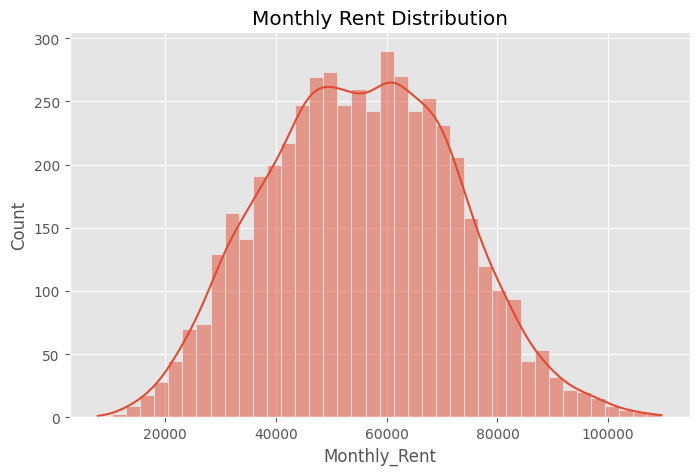

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly_Rent"],bins=40,kde=True)

plt.title("Monthly Rent Distribution")

plt.show()

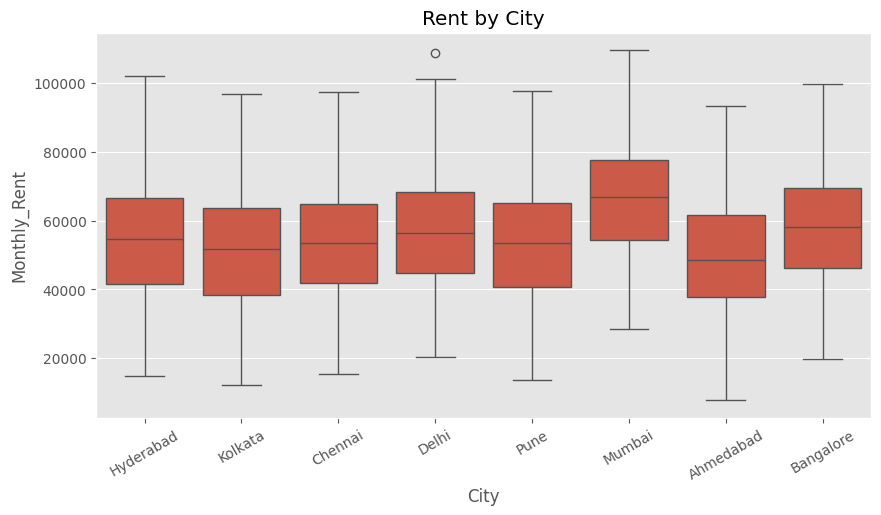

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="City",
    y="Monthly_Rent"
)

plt.xticks(rotation=30)

plt.title("Rent by City")

plt.show()

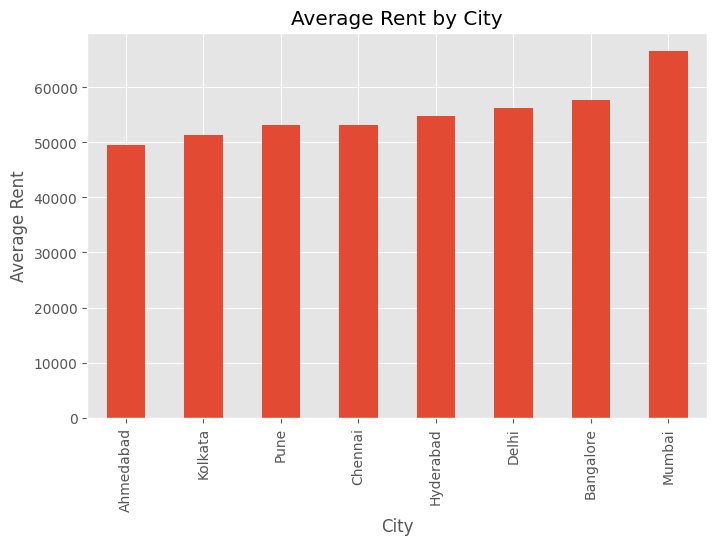

In [ ]:
city_avg = df.groupby("City")["Monthly_Rent"].mean().sort_values()

plt.figure(figsize=(8,5))

city_avg.plot(kind="bar")

plt.ylabel("Average Rent")

plt.title("Average Rent by City")

plt.show()

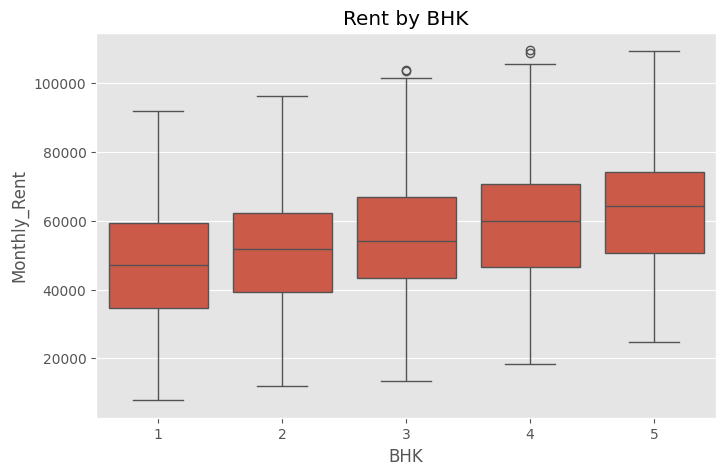

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="BHK",
    y="Monthly_Rent"
)

plt.title("Rent by BHK")

plt.show()

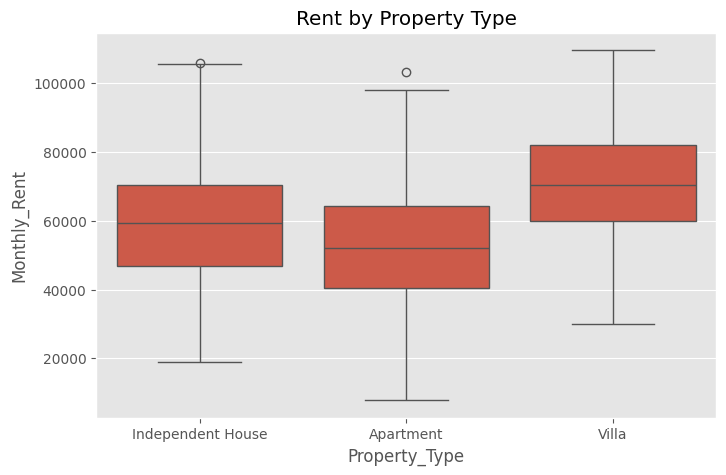

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Property_Type",
    y="Monthly_Rent"
)

plt.title("Rent by Property Type")

plt.show()

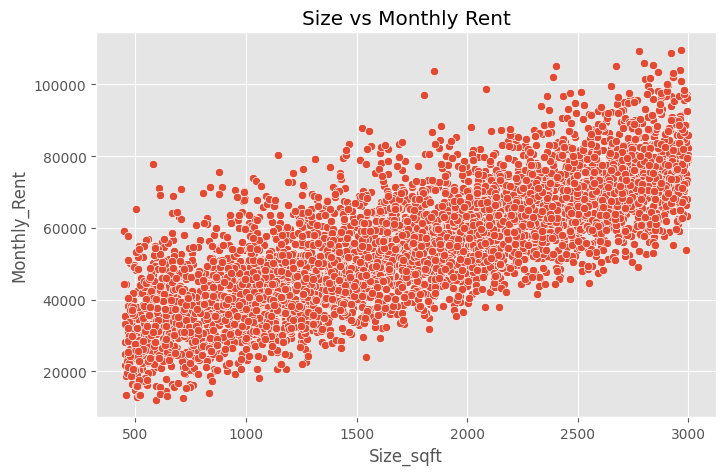

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Size_sqft",
    y="Monthly_Rent"
)

plt.title("Size vs Monthly Rent")

plt.show()

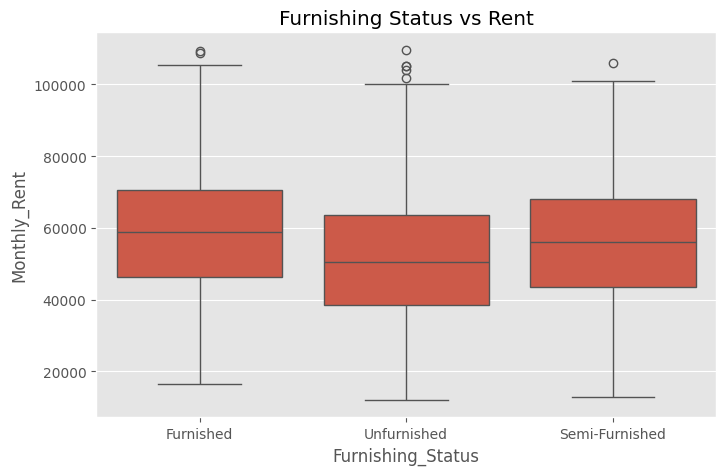

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Furnishing_Status",
    y="Monthly_Rent"
)

plt.title("Furnishing Status vs Rent")

plt.show()

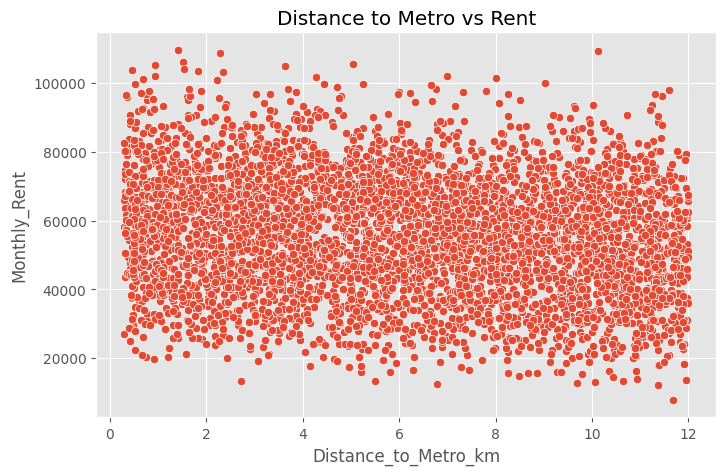

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Distance_to_Metro_km",
    y="Monthly_Rent"
)

plt.title("Distance to Metro vs Rent")

plt.show()

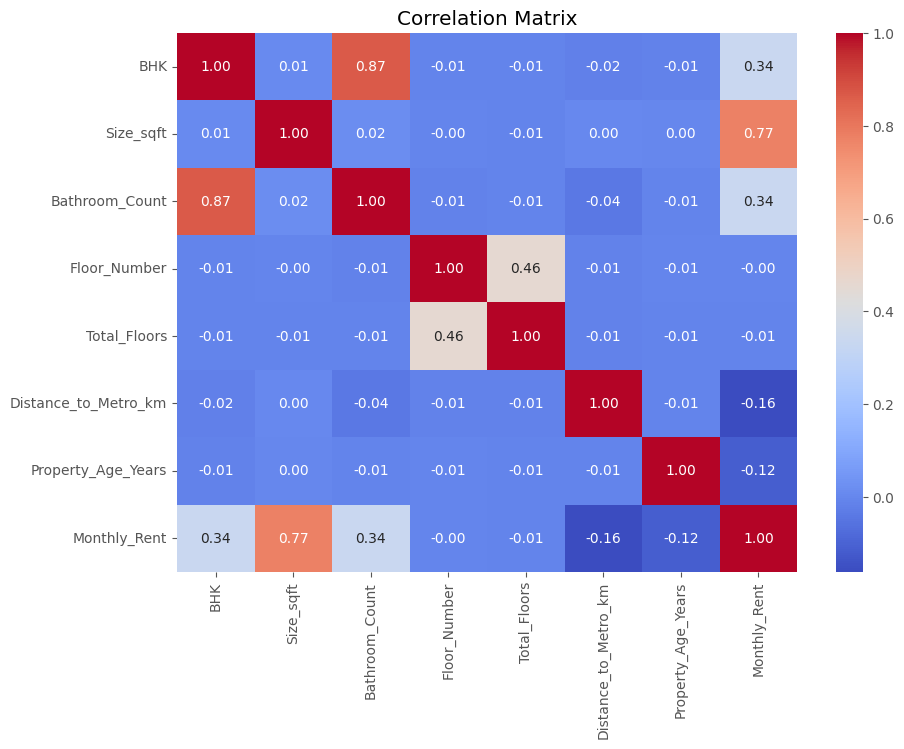

In [ ]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
print("Average Rent by City")

df.groupby("City")["Monthly_Rent"].mean().sort_values(ascending=False)

Average Rent by City


,Monthly_Rent
City,
Mumbai,66618.407692
Bangalore,57741.001623
Delhi,56173.584416
Hyderabad,54716.414400
Chennai,53198.957724
Pune,53142.045234
Kolkata,51367.190551
Ahmedabad,49450.451923


In [ ]:
print("Average Rent by Property Type")

df.groupby("Property_Type")["Monthly_Rent"].mean().sort_values(ascending=False)

Average Rent by Property Type


,Monthly_Rent
Property_Type,
Villa,70648.937500
Independent House,58731.649846
Apartment,52275.215681


In [ ]:
print("Average Rent by Furnishing")

df.groupby("Furnishing_Status")["Monthly_Rent"].mean().sort_values(ascending=False)

Average Rent by Furnishing


,Monthly_Rent
Furnishing_Status,
Furnished,59002.769183
Semi-Furnished,55773.584391
Unfurnished,51133.548139


In [ ]:
print("Average Rent by BHK")

df.groupby("BHK")["Monthly_Rent"].mean()

Average Rent by BHK


,Monthly_Rent
BHK,
1,47191.156477
2,51152.121212
3,54900.058532
4,59394.229147
5,63270.843233


In [ ]:
print("Correlation with Monthly Rent")

df[numerical_columns].corr()["Monthly_Rent"].sort_values(ascending=False)

Correlation with Monthly Rent


,Monthly_Rent
Monthly_Rent,1.000000
Size_sqft,0.774392
Bathroom_Count,0.336791
BHK,0.336479
Floor_Number,-0.003147
Total_Floors,-0.010642
Property_Age_Years,-0.115250
Distance_to_Metro_km,-0.161423


In [ ]:
print("Missing Values Before Treatment:\n")
print(df.isnull().sum())

Missing Values Before Treatment:

Property_ID               0
City                      0
Area_Locality             0
Property_Type             0
BHK                       0
Size_sqft               250
Bathroom_Count          250
Furnishing_Status       250
Floor_Number              0
Total_Floors              0
Parking_Available       250
Distance_to_Metro_km    250
Property_Age_Years        0
Monthly_Rent              0
dtype: int64


In [ ]:
X = df.drop("Monthly_Rent", axis=1)
y = df["Monthly_Rent"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (5000, 13)
Target Shape : (5000,)


In [ ]:
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
['BHK', 'Size_sqft', 'Bathroom_Count', 'Floor_Number', 'Total_Floors', 'Distance_to_Metro_km', 'Property_Age_Years']

Categorical Columns
['Property_ID', 'City', 'Area_Locality', 'Property_Type', 'Furnishing_Status', 'Parking_Available']


In [ ]:
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['BHK', 'Size_sqft', 'Bathroom_Count',
                                  'Floor_Number', 'Total_Floors',
                                  'Distance_to_Metro_km',
                                  'Property_Age_Years']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Property_ID', 'City', 'Area_Locality',
                                  'Property_Type', 'Furnishing_Status',
                                  'Parking_Available'])])

In [ ]:
X_processed = preprocessor.fit_transform(X)

print(type(X_processed))

<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
print("Shape Before Encoding :", X.shape)
print("Shape After Encoding  :", X_processed.shape)

Shape Before Encoding : (5000, 13)
Shape After Encoding  : (5000, 5063)


In [ ]:
import pandas as pd

processed_df = pd.DataFrame.sparse.from_spmatrix(X_processed)

print(processed_df.isnull().sum())

0       False
1       False
2       False
3       False
4       False
        ...  
5058    False
5059    False
5060    False
5061    False
5062    False
Length: 5063, dtype: Sparse[bool, False]


In [ ]:
processed_df.head()

,0,1,2,3,4,5,6,7,8,9,...,5053,5054,5055,5056,5057,5058,5059,5060,5061,5062
0,-0.738314,-0.622405,-1.397906,1.396419,0.672443,-1.103536,0.714244,1.0,0,0,...,0,0,0,1.0,0,1.0,0,0,0,1.0
1,-0.738314,1.22764,-1.397906,0.862466,0.074131,-1.200835,1.247959,0,1.0,0,...,0,0,1.0,0,0,0,0,1.0,0,1.0
2,-0.029759,-1.371468,-0.728026,1.262931,0.522865,0.001714,-0.620043,0,0,1.0,...,0,0,1.0,0,0,1.0,0,0,1.0,0
3,-0.029759,-1.654134,-0.728026,-0.07195,-0.972915,-1.684286,-0.219757,0,0,0,...,0,0,0,0,1.0,1.0,0,0,1.0,0
4,1.38735,-0.751018,0.611734,-1.406831,-0.075447,0.812027,0.981101,0,0,0,...,0,0,0,1.0,0,0,1.0,0,1.0,0


In [ ]:
print("Original Features :", X.shape[1])

print("Features After Encoding :", X_processed.shape[1])

Original Features : 13
Features After Encoding : 5063


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__BHK' 'num__Size_sqft' 'num__Bathroom_Count' ...
 'cat__Furnishing_Status_Unfurnished' 'cat__Parking_Available_No'
 'cat__Parking_Available_Yes']


In [ ]:
print("Total Features After Preprocessing")

print(len(feature_names))

Total Features After Preprocessing
5063


In [ ]:
feature_names[:20]

array(['num__BHK', 'num__Size_sqft', 'num__Bathroom_Count',
       'num__Floor_Number', 'num__Total_Floors',
       'num__Distance_to_Metro_km', 'num__Property_Age_Years',
       'cat__Property_ID_P00001', 'cat__Property_ID_P00002',
       'cat__Property_ID_P00003', 'cat__Property_ID_P00004',
       'cat__Property_ID_P00005', 'cat__Property_ID_P00006',
       'cat__Property_ID_P00007', 'cat__Property_ID_P00008',
       'cat__Property_ID_P00009', 'cat__Property_ID_P00010',
       'cat__Property_ID_P00011', 'cat__Property_ID_P00012',
       'cat__Property_ID_P00013'], dtype=object)

In [ ]:
processed_df = pd.DataFrame.sparse.from_spmatrix(
    X_processed,
    columns=feature_names
)

processed_df.head()

,num__BHK,num__Size_sqft,num__Bathroom_Count,num__Floor_Number,num__Total_Floors,num__Distance_to_Metro_km,num__Property_Age_Years,cat__Property_ID_P00001,cat__Property_ID_P00002,cat__Property_ID_P00003,...,cat__Area_Locality_Wakad,cat__Area_Locality_Whitefield,cat__Property_Type_Apartment,cat__Property_Type_Independent House,cat__Property_Type_Villa,cat__Furnishing_Status_Furnished,cat__Furnishing_Status_Semi-Furnished,cat__Furnishing_Status_Unfurnished,cat__Parking_Available_No,cat__Parking_Available_Yes
0,-0.738314,-0.622405,-1.397906,1.396419,0.672443,-1.103536,0.714244,1.0,0,0,...,0,0,0,1.0,0,1.0,0,0,0,1.0
1,-0.738314,1.22764,-1.397906,0.862466,0.074131,-1.200835,1.247959,0,1.0,0,...,0,0,1.0,0,0,0,0,1.0,0,1.0
2,-0.029759,-1.371468,-0.728026,1.262931,0.522865,0.001714,-0.620043,0,0,1.0,...,0,0,1.0,0,0,1.0,0,0,1.0,0
3,-0.029759,-1.654134,-0.728026,-0.07195,-0.972915,-1.684286,-0.219757,0,0,0,...,0,0,0,0,1.0,1.0,0,0,1.0,0
4,1.38735,-0.751018,0.611734,-1.406831,-0.075447,0.812027,0.981101,0,0,0,...,0,0,0,1.0,0,0,1.0,0,1.0,0


In [ ]:
print("="*50)

print("Preprocessing Completed Successfully")

print("="*50)

print("Original Dataset Shape :", X.shape)

print("Processed Dataset Shape :", processed_df.shape)

print("Missing Values Remaining :", processed_df.isnull().sum().sum())

Preprocessing Completed Successfully
Original Dataset Shape : (5000, 13)
Processed Dataset Shape : (5000, 5063)
Missing Values Remaining : 0


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
X = df.drop("Monthly_Rent", axis=1)
y = df["Monthly_Rent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (4000, 13)
Testing Features  : (1000, 13)

Training Target : (4000,)
Testing Target  : (1000,)


In [ ]:
numerical_columns = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
['BHK', 'Size_sqft', 'Bathroom_Count', 'Floor_Number', 'Total_Floors', 'Distance_to_Metro_km', 'Property_Age_Years']

Categorical Columns
['Property_ID', 'City', 'Area_Locality', 'Property_Type', 'Furnishing_Status', 'Parking_Available']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['BHK', 'Size_sqft', 'Bathroom_Count',
                                  'Floor_Number', 'Total_Floors',
                                  'Distance_to_Metro_km',
                                  'Property_Age_Years']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Property_ID', 'City', 'Area_Locality',
                                  'Property_Type', 'Furnishing_Status',
                                  'Parking_Available'])])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

Training Shape : (4000, 4063)
Testing Shape  : (1000, 4063)


In [ ]:
dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(X_train_processed, y_train)

DummyRegressor()

In [ ]:
dummy_predictions = dummy_model.predict(X_test_processed)

dummy_predictions[:10]

array([55382.84325, 55382.84325, 55382.84325, 55382.84325, 55382.84325,
       55382.84325, 55382.84325, 55382.84325, 55382.84325, 55382.84325])

In [ ]:
dummy_mae = mean_absolute_error(
    y_test,
    dummy_predictions
)

print("Dummy MAE :", dummy_mae)

Dummy MAE : 14087.0937025


In [ ]:
dummy_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dummy_predictions
    )
)

print("Dummy RMSE :", dummy_rmse)

Dummy RMSE : 17218.99543893029


In [ ]:
dummy_r2 = r2_score(
    y_test,
    dummy_predictions
)

print("Dummy R² :", dummy_r2)

Dummy R² : -8.163854646747737e-05


In [ ]:
baseline_results = {
    "Model": "Dummy Regressor",
    "MAE": dummy_mae,
    "RMSE": dummy_rmse,
    "R2 Score": dummy_r2
}

baseline_results

{'Model': 'Dummy Regressor',
 'MAE': 14087.0937025,
 'RMSE': np.float64(17218.99543893029),
 'R2 Score': -8.163854646747737e-05}

In [ ]:
import pandas as pd

baseline_df = pd.DataFrame({
    "Model": ["Dummy Regressor"],
    "MAE": [dummy_mae],
    "RMSE": [dummy_rmse],
    "R2 Score": [dummy_r2]
})

baseline_df

,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,14087.093703,17218.995439,-0.000082


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
input_dim = X_train_processed.shape[1]

print("Number of Input Features :", input_dim)

Number of Input Features : 4063


In [ ]:
ann_model = Sequential([

    Input(shape=(input_dim,)),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)

])

In [ ]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       520,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,561 (2.02 MB)

 Trainable params: 530,561 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=["mae"]

)

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

In [ ]:
history = ann_model.fit(

    X_train_processed,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 3348659456.0000 - mae: 55334.2109 - val_loss: 3257655552.0000 - val_mae: 54625.3398
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2851935232.0000 - mae: 50752.3438 - val_loss: 1966011648.0000 - val_mae: 41861.9570
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 828892928.0000 - mae: 23845.0000 - val_loss: 114627952.0000 - val_mae: 8555.3369
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 104978584.0000 - mae: 8059.6201 - val_loss: 59211060.0000 - val_mae: 6150.4858
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 75984696.0000 - mae: 6770.5312 - val_loss: 37916880.0000 - val_mae: 4883.5776
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 59085508.0000 - mae: 5974.2944 - val_loss: 27554320.0000 - val_mae: 4041.7939
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 48848824.0000 - mae: 5472.9512 - val_loss: 20065972.0000 - val_mae: 3434.2800
Epoc

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [ ]:
print("Training Stopped After")

print(len(history.history["loss"]))

print("Epochs")

Training Stopped After
35
Epochs


In [ ]:
print("Final Training Loss")

print(history.history["loss"][-1])

Final Training Loss
32264888.0


In [ ]:
print("Final Validation Loss")

print(history.history["val_loss"][-1])

Final Validation Loss
9607605.0


In [ ]:
print("Final Training MAE")

print(history.history["mae"][-1])

Final Training MAE
4397.08447265625


In [ ]:
print("Final Validation MAE")

print(history.history["val_mae"][-1])

Final Validation MAE
2516.435546875


In [ ]:
best_loss = min(history.history["val_loss"])

print("Best Validation Loss")

print(best_loss)

Best Validation Loss
8203474.0


In [ ]:
best_mae = min(history.history["val_mae"])

print("Best Validation MAE")

print(best_mae)

Best Validation MAE
2293.4384765625


In [ ]:
print("="*50)

print("ANN Training Completed Successfully")

print("="*50)

print("Training Samples :", X_train_processed.shape[0])

print("Testing Samples :", X_test_processed.shape[0])

print("Input Features :", input_dim)

print("Output Neurons : 1")

print("Loss Function : Mean Squared Error")

print("Optimizer : Adam")

print("Metric : Mean Absolute Error")

print("="*50)

ANN Training Completed Successfully
Training Samples : 4000
Testing Samples : 1000
Input Features : 4063
Output Neurons : 1
Loss Function : Mean Squared Error
Optimizer : Adam
Metric : Mean Absolute Error


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
ann_predictions = ann_model.predict(X_test_processed)

ann_predictions[:10]

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


array([[53801.902],
       [46704.543],
       [49593.03 ],
       [39066.55 ],
       [59642.12 ],
       [44936.332],
       [53393.77 ],
       [67484.336],
       [56591.484],
       [68010.13 ]], dtype=float32)

In [ ]:
ann_predictions = ann_predictions.flatten()

ann_predictions[:10]

array([53801.902, 46704.543, 49593.03 , 39066.55 , 59642.12 , 44936.332,
       53393.77 , 67484.336, 56591.484, 68010.13 ], dtype=float32)

In [ ]:
ann_mae = mean_absolute_error(
    y_test,
    ann_predictions
)

print("ANN MAE :", ann_mae)

ANN MAE : 4544.75439453125


In [ ]:
ann_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ann_predictions
    )
)

print("ANN RMSE :", ann_rmse)

ANN RMSE : 7045.482524284621


In [ ]:
ann_r2 = r2_score(
    y_test,
    ann_predictions
)

print("ANN R² Score :", ann_r2)

ANN R² Score : 0.8325668573379517


In [ ]:
loss, mae = ann_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Test Loss :", loss)
print("Test MAE  :", mae)

Test Loss : 49638832.0
Test MAE  : 4544.75439453125


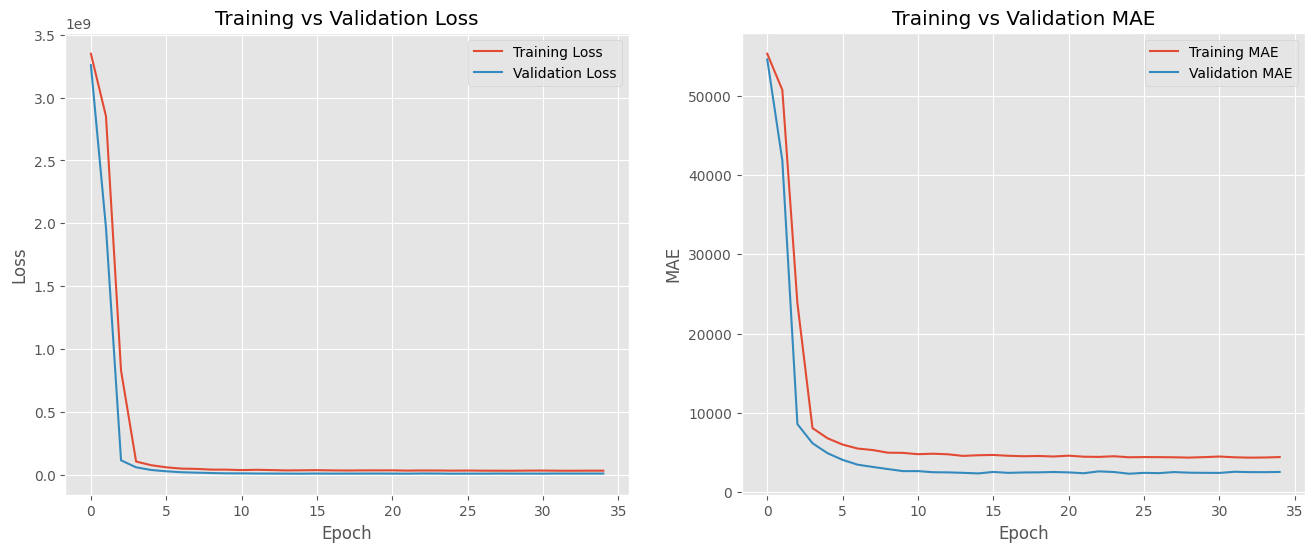

In [ ]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)


plt.subplot(1,2,2)

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Training vs Validation MAE")

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.legend()

plt.grid(True)

plt.show()

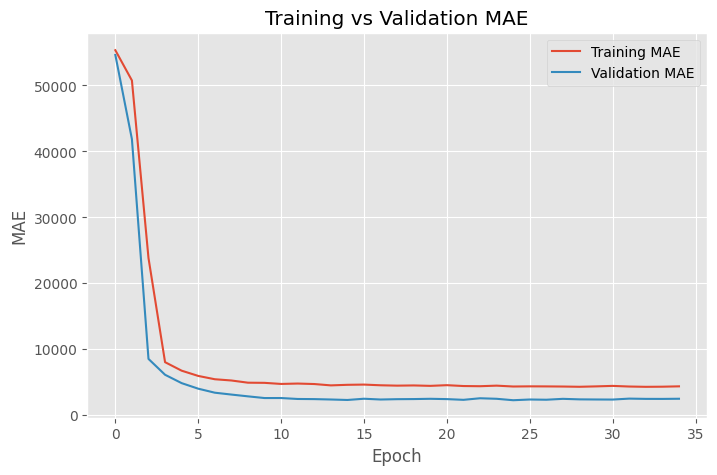

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Dummy Regressor",
        "ANN Regressor"
    ],

    "MAE":[
        dummy_mae,
        ann_mae
    ],

    "RMSE":[
        dummy_rmse,
        ann_rmse
    ],

    "R2 Score":[
        dummy_r2,
        ann_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,14087.093703,17218.995439,-0.000082
1,ANN Regressor,4544.754395,7045.482524,0.832567


In [ ]:
comparison.round(2)

,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,14087.09,17219.00,-0.00
1,ANN Regressor,4544.75,7045.48,0.83


In [ ]:
if ann_mae < dummy_mae:
    print("✅ ANN has lower MAE than Dummy Regressor.")
else:
    print("❌ ANN did not improve MAE.")

print()

if ann_rmse < dummy_rmse:
    print("✅ ANN has lower RMSE than Dummy Regressor.")
else:
    print("❌ ANN did not improve RMSE.")

print()

if ann_r2 > dummy_r2:
    print("✅ ANN has higher R² Score than Dummy Regressor.")
else:
    print("❌ ANN did not improve R² Score.")

✅ ANN has lower MAE than Dummy Regressor.

✅ ANN has lower RMSE than Dummy Regressor.

✅ ANN has higher R² Score than Dummy Regressor.


In [ ]:
results = pd.DataFrame({

    "Actual Rent": y_test.values,

    "Predicted Rent": ann_predictions

})

results.head(10)

,Actual Rent,Predicted Rent
0,35685,53801.902344
1,46832,46704.542969
2,68681,49593.031250
3,21055,39066.550781
4,78701,59642.121094
5,32182,44936.332031
6,57292,53393.769531
7,68279,67484.335938
8,72871,56591.484375
9,83870,68010.132812


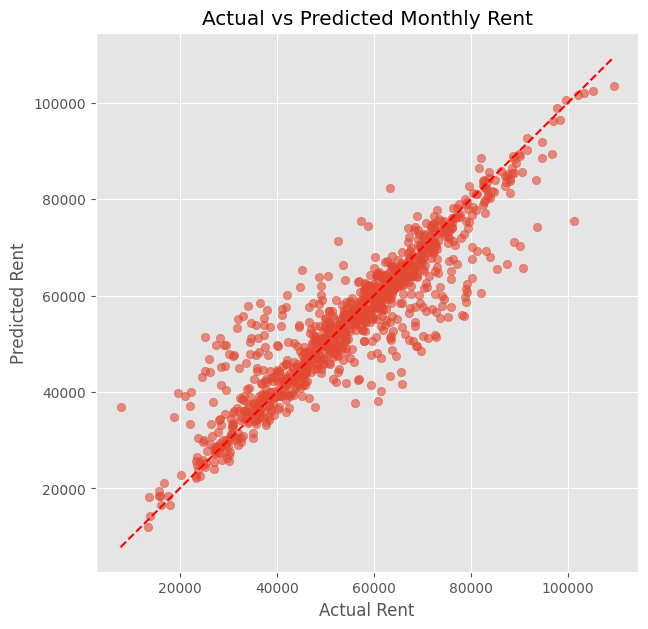

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    ann_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Rent")

plt.ylabel("Predicted Rent")

plt.title("Actual vs Predicted Monthly Rent")

plt.grid(True)

plt.show()

In [ ]:
errors = y_test.values - ann_predictions

print("Minimum Error :", errors.min())
print("Maximum Error :", errors.max())
print("Average Error :", np.mean(np.abs(errors)))

Minimum Error : -29008.17578125
Maximum Error : 25575.328125
Average Error : 4544.754604492187


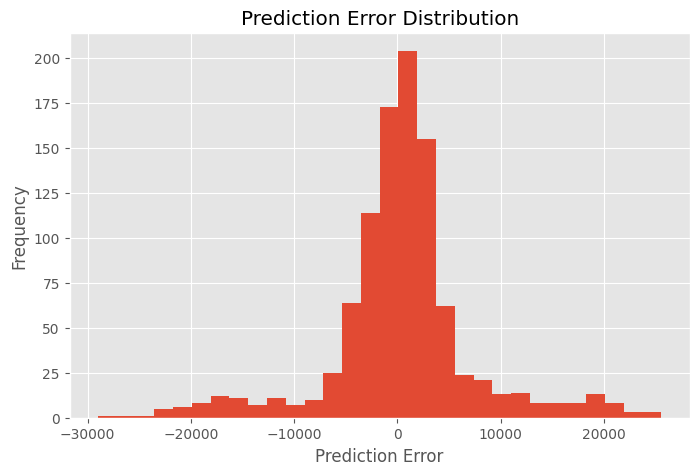

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [ ]:
print("="*50)

print("ANN MODEL EVALUATION")

print("="*50)

print(f"MAE      : {ann_mae:.2f}")

print(f"RMSE     : {ann_rmse:.2f}")

print(f"R² Score : {ann_r2:.4f}")

print("="*50)

ANN MODEL EVALUATION
MAE      : 4544.75
RMSE     : 7045.48
R² Score : 0.8326


In [ ]:
new_property = pd.DataFrame({

    "Property_ID": ["P5001"],

    "City": ["Bangalore"],

    "Area_Locality": ["Whitefield"],

    "Property_Type": ["Apartment"],

    "BHK": [2],

    "Size_sqft": [1050],

    "Bathroom_Count": [2],

    "Furnishing_Status": ["Semi-Furnished"],

    "Floor_Number": [5],

    "Total_Floors": [12],

    "Parking_Available": ["Yes"],

    "Distance_to_Metro_km": [1.5],

    "Property_Age_Years": [4]

})

new_property

,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years
0,P5001,Bangalore,Whitefield,Apartment,2,1050,2,Semi-Furnished,5,12,Yes,1.5,4


In [ ]:
new_property_processed = preprocessor.transform(new_property)

print(new_property_processed.shape)

(1, 4063)


In [ ]:
predicted_rent = ann_model.predict(new_property_processed)

predicted_rent

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


array([[44625.242]], dtype=float32)

In [ ]:
print("="*50)

print("Predicted Monthly Rent")

print("="*50)

print(f"₹ {predicted_rent[0][0]:,.2f}")

print("="*50)

Predicted Monthly Rent
₹ 44,625.24


In [ ]:
ann_model.save("house_rent_ann.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("house_rent_ann.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
loaded_prediction = loaded_model.predict(new_property_processed)

print(f"Predicted Rent : ₹ {loaded_prediction[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Predicted Rent : ₹ 44,625.24


In [ ]:
import joblib

joblib.dump(preprocessor, "house_rent_preprocessor.pkl")

print("Preprocessor Saved Successfully")

Preprocessor Saved Successfully


In [ ]:
loaded_preprocessor = joblib.load("house_rent_preprocessor.pkl")

print("Preprocessor Loaded Successfully")

Preprocessor Loaded Successfully


In [ ]:
final_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R² Score"
    ],

    "Value":[
        ann_mae,
        ann_rmse,
        ann_r2
    ]

})

final_results

,Metric,Value
0,MAE,4544.754395
1,RMSE,7045.482524
2,R² Score,0.832567
